## Customer Churn Data Analysis using Python

This project analyzes customer churn data to understand patterns in customer behavior and identify factors influencing churn.
This project focuses on cleaning, analyzing, and visualizing customer churn data to understand patterns in customer behavior.

## Import Required Libraries 

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('churn_data.csv')
df.head(10)

,customerID,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,2,Yes,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,8,Yes,Month-to-month,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,22,Yes,Month-to-month,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,10,No,Month-to-month,Mailed check,29.75,301.90,No
8,7892-POOKP,28,Yes,Month-to-month,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,62,Yes,One year,Bank transfer (automatic),56.15,3487.95,No


 ### Data Overview
Understanding dataset structure and missing values

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerID      7043 non-null   object 
 1   tenure          7043 non-null   int64  
 2   PhoneService    7043 non-null   object 
 3   Contract        7043 non-null   object 
 4   PaymentMethod   7043 non-null   object 
 5   MonthlyCharges  7043 non-null   float64
 6   TotalCharges    7032 non-null   float64
 7   Churn           7043 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 440.3+ KB


In [50]:
df.shape

(7043, 8)

In [67]:
# Missing Values 
df.isna().sum()

customerID         0
tenure             0
PhoneService       0
Contract           0
PaymentMethod      0
MonthlyCharges     0
TotalCharges      11
Churn              0
dtype: int64

###  Data Cleaning
Handling missing values and removing inconsistencies

In [68]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())

# Drop unnecessary column
df = df.drop("customerID", axis=1)

# Remove duplicates
df = df.drop_duplicates()

# Clean column names
df.columns = df.columns.str.strip()

# Verify cleaning
df.isna().sum()

tenure            0
PhoneService      0
Contract          0
PaymentMethod     0
MonthlyCharges    0
TotalCharges      0
Churn             0
dtype: int64



In this step, the dataset was prepared for analysis by handling missing values, correcting data types, and removing unnecessary columns. 

The 'TotalCharges' column was converted to numeric format, and missing values were replaced using the mean to maintain data consistency. 

The 'customerID' column was removed as it does not contribute to analysis. Duplicate records were also checked and removed to ensure data quality.

These steps ensure that the dataset is clean, consistent, and ready for further analysis.

### DATA TYPE CONVERSION

In [69]:
# Convert categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [70]:
### Feature Engineering
# Create new feature: TotalCharges to Tenure Ratio
df["TotalCharges_to_Tenure_Ratio"] = (
    df["TotalCharges"] / df["tenure"].replace(0, 1)
)

# Create yearly charges
df["YearlyCharges"] = df["MonthlyCharges"] * 12

# Create tenure groups
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-6yr"]
)



New features were created to enhance the analysis and gain deeper insights into customer behavior.

A new feature 'TotalCharges_to_Tenure_Ratio' was created to understand customer spending relative to their tenure.

Additionally, 'YearlyCharges' was derived from monthly charges to represent annual spending.

Customers were also grouped into tenure categories using binning to analyze churn behavior across different time periods.

These engineered features help in uncovering patterns that are not directly visible in the original dataset.

### OUTLIER REMOVAL (IQR METHOD)

In [71]:
# Calculate IQR
Q1 = df["TotalCharges_to_Tenure_Ratio"].quantile(0.25)
Q3 = df["TotalCharges_to_Tenure_Ratio"].quantile(0.75)

IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_clean = df[
    (df["TotalCharges_to_Tenure_Ratio"] >= lower_bound) &
    (df["TotalCharges_to_Tenure_Ratio"] <= upper_bound)
]

# Check size
print("Original:", df.shape)
print("After cleaning:", df_clean.shape)

Original: (6932, 10)
After cleaning: (6921, 10)




Outliers were identified and removed to improve the quality of the analysis and reduce the impact of extreme values.

The Interquartile Range (IQR) method was used to detect outliers in the 'TotalCharges_to_Tenure_Ratio' feature. Values outside the acceptable range were filtered out.

Removing outliers helps in producing more accurate visualizations and reliable insights by minimizing distortion caused by extreme data points.

### EXPLORATORY DATA ANALYSIS

In [72]:
# Churn distribution
df_clean["Churn"].value_counts()

# Contract distribution
df_clean["Contract"].value_counts()

# Payment method distribution
df_clean["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2320
Mailed check                 1541
Bank transfer (automatic)    1540
Credit card (automatic)      1520
Name: count, dtype: int64

### GROUPBY ANALYSIS

In [73]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.584441
Yes    75.196534
Name: MonthlyCharges, dtype: float64

In [74]:
df.groupby("Churn")["TotalCharges"].mean()

Churn
No     2576.962167
Yes    1585.898724
Name: TotalCharges, dtype: float64

In [75]:
df.groupby("Contract")["Churn"].value_counts()

Contract        Churn
Month-to-month  No       2175
                Yes      1589
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [76]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.890817
Yes    18.600666
Name: tenure, dtype: float64



In this step, the dataset was analyzed to understand patterns, distributions, and relationships between variables.

Techniques such as value_counts were used to examine the distribution of categorical variables like 'Churn', 'Contract', and 'PaymentMethod'.

Groupby and aggregation functions were applied to compare numerical features such as 'MonthlyCharges', 'TotalCharges', and 'tenure' across different customer segments.

This step helps in identifying key patterns and trends in the data before visualization.

### VISUALIZATION

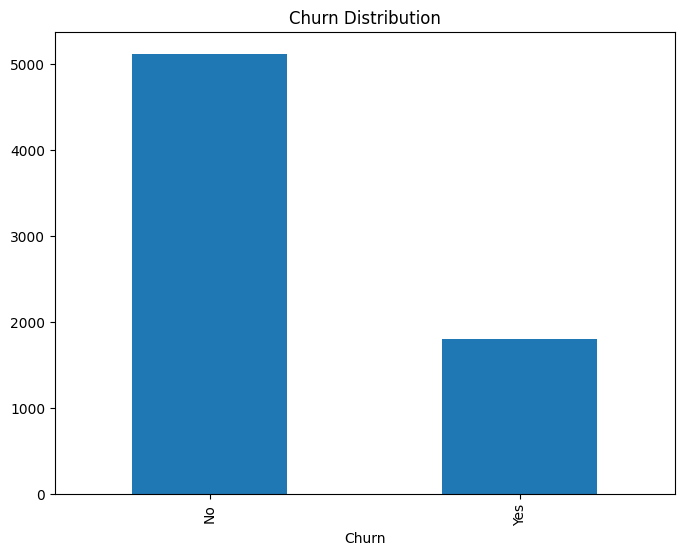

In [77]:
# Churn distribution
plt.figure(figsize=(8,6))
df_clean["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()

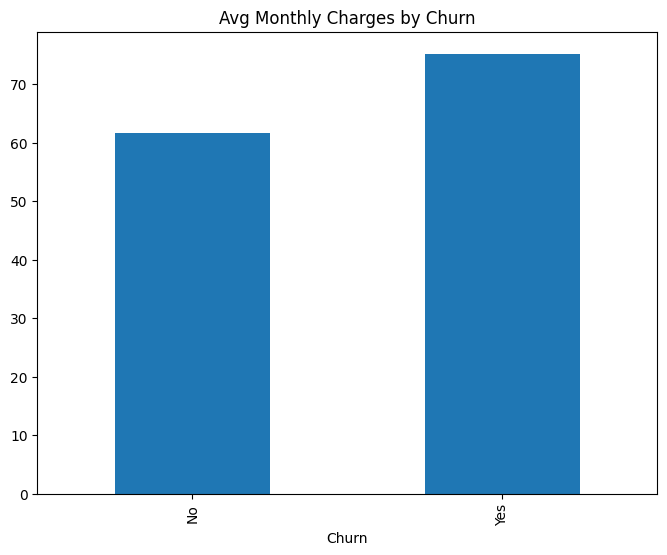

In [78]:
# Monthly charges vs churn
plt.figure(figsize=(8,6))
df_clean.groupby("Churn")["MonthlyCharges"].mean().plot(kind="bar")
plt.title("Avg Monthly Charges by Churn")
plt.show()

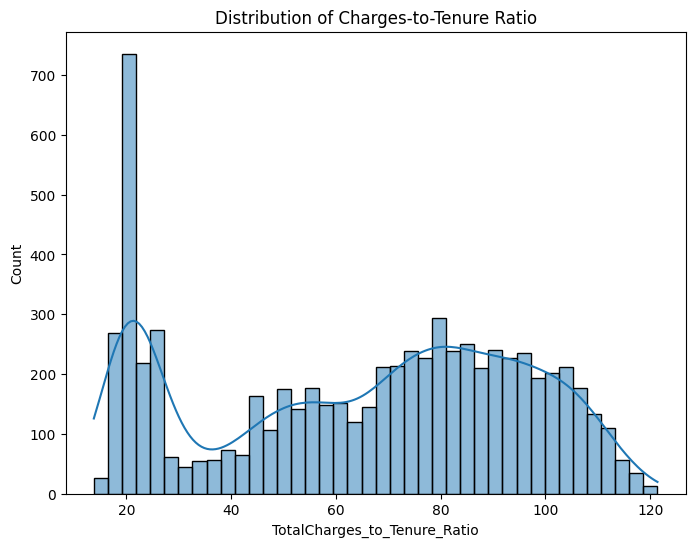

In [79]:
# Ratio distribution
plt.figure(figsize=(8,6))
sns.histplot(df_clean["TotalCharges_to_Tenure_Ratio"], bins=40, kde=True)
plt.title("Distribution of Charges-to-Tenure Ratio")
plt.show()

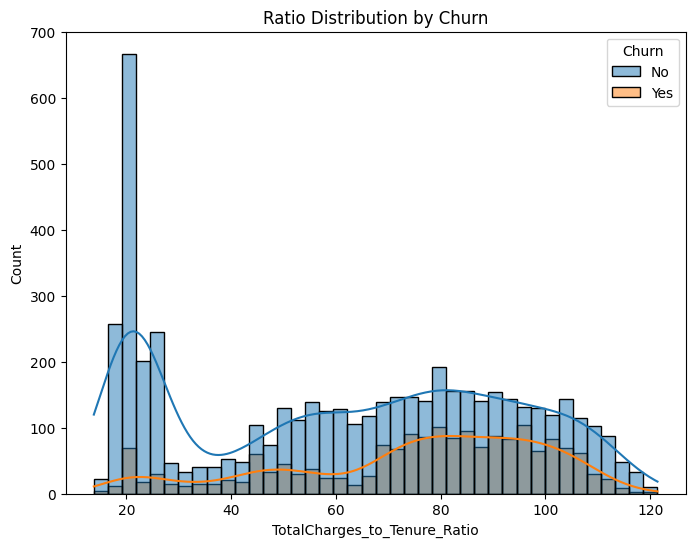

In [80]:
# Ratio vs churn
plt.figure(figsize=(8,6))
sns.histplot(
    data=df_clean,
    x="TotalCharges_to_Tenure_Ratio",
    hue="Churn",
    bins=40,
    kde=True
)
plt.title("Ratio Distribution by Churn")
plt.show()



Visualizations were created to better understand patterns and trends in the dataset.

Bar charts were used to analyze the distribution of churn and categorical variables, while histograms were used to understand the distribution of numerical features.

Additionally, comparisons were made between churned and non-churned customers to identify differences in behavior.

Visualization helps in presenting insights clearly and making the analysis more interpretable.

## Insights

• The dataset shows that a larger number of customers do not churn compared to those who churn  

• Customers with higher monthly charges tend to have a higher likelihood of churning  

• Contract type plays an important role, with certain contract categories showing different churn behavior  

• Customers with shorter tenure are more likely to churn compared to long-term customers  

• The TotalCharges-to-Tenure ratio highlights differences in customer spending patterns  